In [2]:
# Import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Read in data to dataframe
data_frame = pd.read_csv("NetFlix.csv")

In [3]:
# Check data has read in correctly
data_frame.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...
5,s1002,Movie,Blue Ruin,Jeremy Saulnier,"Macon Blair, Devin Ratray, Amy Hargreaves, Kev...","United States, France",25-Feb-19,2013,R,90,"Independent Movies, Thrillers",Bad news from the past unhinges vagabond Dwigh...
6,s1003,Movie,Blue Streak,Les Mayfield,"Martin Lawrence, Luke Wilson, Peter Greene, Da...","Germany, United States",1-Jan-21,1999,PG-13,94,"Action & Adventure, Comedies",A jewel thief returns to his hiding place afte...
7,s1004,Movie,Blue Valentine,Derek Cianfrance,"Ryan Gosling, Michelle Williams, Faith Wladyka...",United States,5-Jul-18,2010,R,112,"Dramas, Independent Movies, Romantic Movies",As Cindy and Dean muddle through their languis...
8,s1005,Movie,BluffMaster!,Rohan Sippy,"Abhishek Bachchan, Priyanka Chopra, Riteish De...",India,8-Jan-21,2005,TV-14,129,"Comedies, International Movies, Romantic Movies",When his girlfriend learns the truth about his...
9,s1006,Movie,Blurred Lines: Inside the Art World,Barry Avrich,NaN,Canada,31-Dec-17,2017,TV-MA,85,Documentaries,Artists and industry insiders shed light on th...


In [4]:
# Check dimensions of dataframe
data_frame.shape

(7787, 12)

In [5]:
# Check column names and types of data
data_frame.info

<bound method DataFrame.info of      show_id     type                                      title  \
0         s1  TV Show                                         3%   
1        s10    Movie                                       1920   
2       s100    Movie                                 3 Heroines   
3      s1000    Movie  Blue Mountain State: The Rise of Thadland   
4      s1001  TV Show                             Blue Planet II   
...      ...      ...                                        ...   
7782    s995  TV Show                                 Blown Away   
7783    s996  TV Show                              Blue Exorcist   
7784    s997    Movie                  Blue Is the Warmest Color   
7785    s998    Movie                               Blue Jasmine   
7786    s999    Movie                                   Blue Jay   

                 director                                               cast  \
0                     NaN  João Miguel, Bianca Comparato, Michel Gomes,

In [6]:
# Check for missing values
data_frame.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

In [7]:
# List of column names
data_frame.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description'],
      dtype='object')

In [8]:
# Are there any duplicated entries?
data_frame.duplicated().sum()

0

In [9]:
# Check the stats of the dataframe, including most common value in each column 
data_frame.describe(include = "object")

,show_id,type,title,director,cast,country,date_added,rating,genres,description
count,7787,7787,7787,5398,7069,7280,7777,7780,7787,7787
unique,7787,2,7787,4049,6831,681,1565,14,492,7769
top,s1,Movie,3%,"Raúl Campos, Jan Suter",David Attenborough,United States,1-Jan-20,TV-MA,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,2863,334,3


In [10]:
# Count the top 15 genre types in the dataframe
data_frame["genres"].value_counts().head(15)

genres
Documentaries                                       334
Stand-Up Comedy                                     321
Dramas, International Movies                        320
Comedies, Dramas, International Movies              243
Dramas, Independent Movies, International Movies    215
Kids' TV                                            205
Children & Family Movies                            177
Documentaries, International Movies                 172
Children & Family Movies, Comedies                  169
Comedies, International Movies                      161
Dramas, International Movies, Romantic Movies       153
Comedies, International Movies, Romantic Movies     139
Dramas                                              117
Action & Adventure, Dramas, International Movies    117
International TV Shows, TV Dramas                   111
Name: count, dtype: int64

In [14]:
data_frame.iloc[[14]]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
14,s1010,Movie,Bo Burnham: what.,"Bo Burnham, Christopher Storer",Bo Burnham,United States,1-Jul-18,2013,TV-MA,60,Stand-Up Comedy,Left brain and right brain duke it out – and u...


In [19]:
# Save the number of movie vs tv show entries as a percentage in a variable
percentage_type = data_frame["type"].value_counts(normalize = True) * 100

In [20]:
percentage_type

type
Movie      69.050982
TV Show    30.949018
Name: proportion, dtype: float64

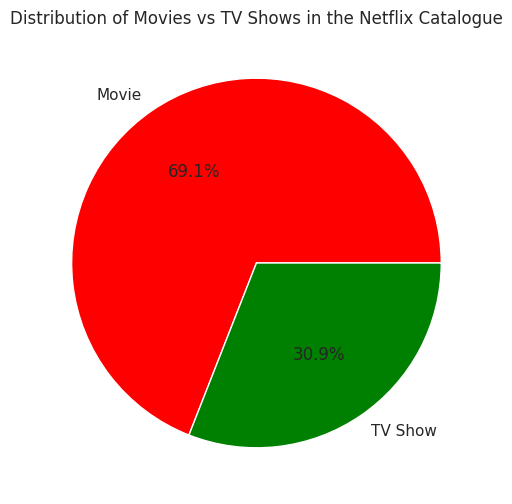

In [24]:
# Pie Chart depicting the distibution of movie vs TV show 
sns.set_theme(style = "white")
plt.figure(figsize = (6, 6))

plt.pie(percentage_type, 
        labels = percentage_type.index, 
        autopct = "%1.1f%%", 
        colors = ["red", "green"])
plt.title("Distribution of Movies vs TV Shows in the Netflix Catalogue")

plt.show()

In [29]:
# Separate the groups of genres in each entry and store in a variable
genres_split = data_frame["genres"].str.split(", ").explode()

In [33]:
# Count the number of times each genre appears and store in a variable
genres_count = genres_split.value_counts()
genres_count

genres
International Movies            2437
Dramas                          2106
Comedies                        1471
International TV Shows          1199
Documentaries                    786
Action & Adventure               721
TV Dramas                        704
Independent Movies               673
Children & Family Movies         532
Romantic Movies                  531
TV Comedies                      525
Thrillers                        491
Crime TV Shows                   427
Kids' TV                         414
Docuseries                       353
Romantic TV Shows                333
Stand-Up Comedy                  329
Music & Musicals                 321
Horror Movies                    312
British TV Shows                 232
Reality TV                       222
Sci-Fi & Fantasy                 218
Sports Movies                    196
Korean TV Shows                  150
TV Action & Adventure            150
Anime Series                     148
Spanish-Language TV Shows      

In [34]:
# Take the most and least popular genres in the database and store them in variables
top_genres = genres_count.head(10)
bottom_genres = genres_count.tail(10) 

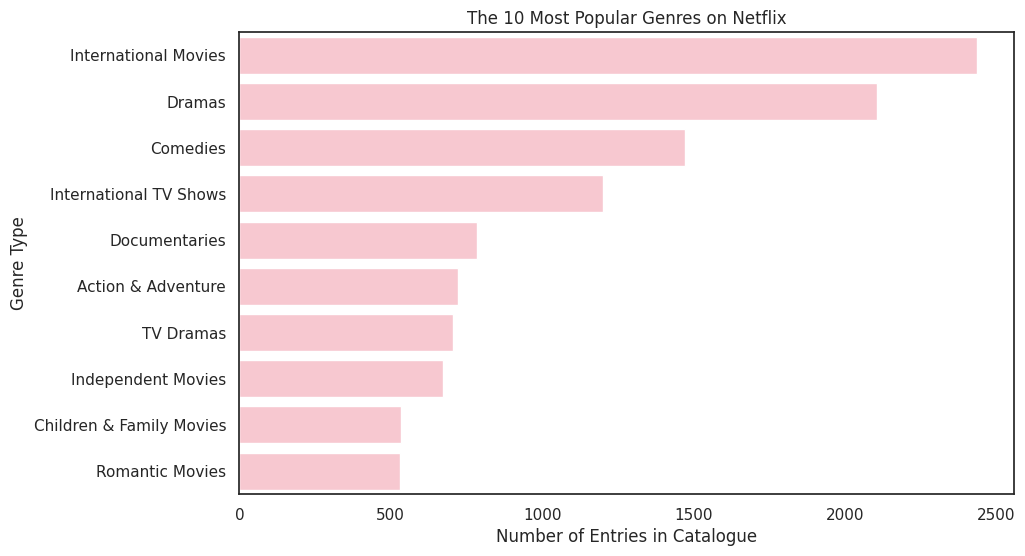

In [41]:
# Plot a barplot to visualise the highest contributed genres in the database

plt.figure(figsize = (10, 6))

sns.barplot(x = top_genres.values,
            y = top_genres.index,
           color = "pink")

plt.title("The 10 Most Popular Genres on Netflix")
plt.xlabel("Number of Entries in Catalogue")
plt.ylabel("Genre Type")

plt.show()

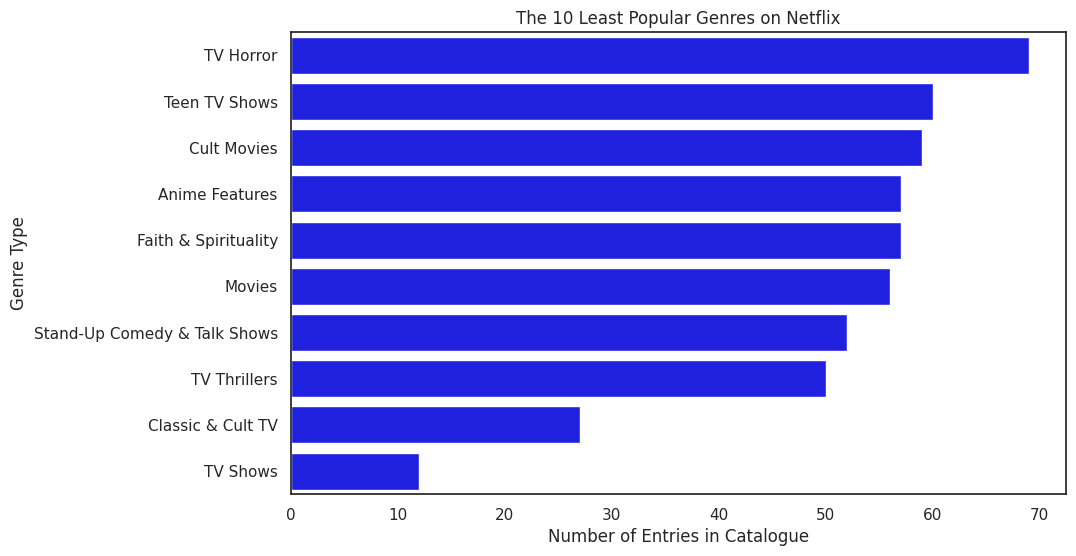

In [42]:
# Plot a barplot to visualise the lowest contributed genres in the database

plt.figure(figsize = (10, 6))

sns.barplot(x = bottom_genres.values,
            y = bottom_genres.index,
            color = "blue")

plt.title("The 10 Least Popular Genres on Netflix")
plt.xlabel("Number of Entries in Catalogue")
plt.ylabel("Genre Type")

plt.show()

In [5]:
# Count the number of times each country appears in the entries
country_count = data_frame["country"].value_counts()

In [10]:
# Store the 5 highest contributing countries in variables
country_top = country_count.head(5)

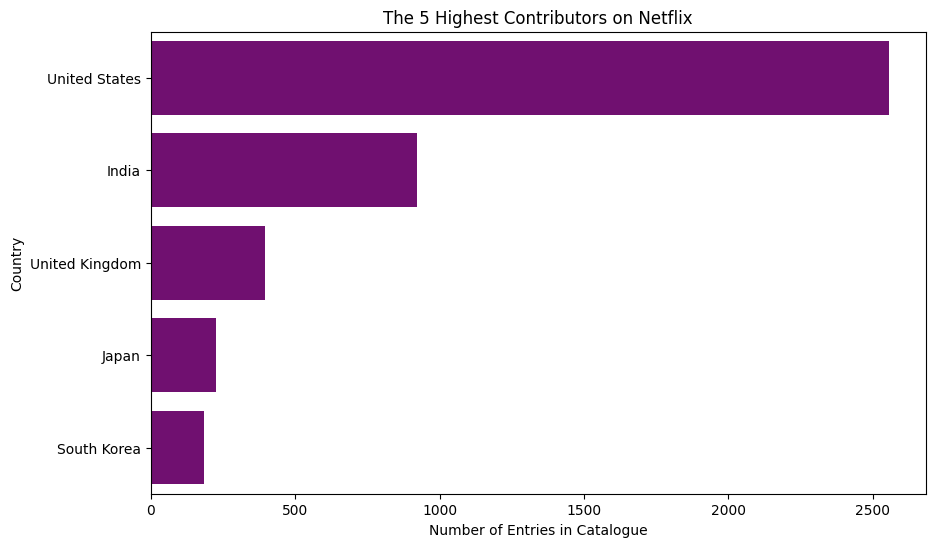

In [8]:
# Plot a barplot to visualise the highest contributing countries in the database

plt.figure(figsize = (10, 6))

sns.barplot(x = country_top.values,
            y = country_top.index,
            color = "purple")

plt.title("The 5 Highest Contributors on Netflix")
plt.xlabel("Number of Entries in Catalogue")
plt.ylabel("Country")

plt.show()

In [15]:
# Convert date_added column from object to datetime
data_frame["date_added"] = pd.to_datetime(data_frame["date_added"])

/tmp/ipykernel_28/800092963.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_frame["date_added"] = pd.to_datetime(data_frame["date_added"])


In [16]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7787 non-null   object        
 1   type          7787 non-null   object        
 2   title         7787 non-null   object        
 3   director      5398 non-null   object        
 4   cast          7069 non-null   object        
 5   country       7280 non-null   object        
 6   date_added    7777 non-null   datetime64[ns]
 7   release_year  7787 non-null   int64         
 8   rating        7780 non-null   object        
 9   duration      7787 non-null   int64         
 10  genres        7787 non-null   object        
 11  description   7787 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(9)
memory usage: 730.2+ KB


In [19]:
# Create 2 sub-columns displaying month and year from the date_added column
data_frame["year_added"] = data_frame["date_added"].dt.year
data_frame["month_added"] = data_frame["date_added"].dt.month_name()

In [21]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7787 non-null   object        
 1   type          7787 non-null   object        
 2   title         7787 non-null   object        
 3   director      5398 non-null   object        
 4   cast          7069 non-null   object        
 5   country       7280 non-null   object        
 6   date_added    7777 non-null   datetime64[ns]
 7   release_year  7787 non-null   int64         
 8   rating        7780 non-null   object        
 9   duration      7787 non-null   int64         
 10  genres        7787 non-null   object        
 11  description   7787 non-null   object        
 12  year_added    7777 non-null   float64       
 13  month_added   7777 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(10)
memory usage: 851.8+ KB


In [22]:
# Create a list of months in order
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

In [23]:
# Ensure the months will appear in order when used in a visualisation
data_frame["month_added"] = pd.Categorical(data_frame["month_added"], categories = months, ordered = True) 

In [24]:
data_frame[["year_added", "month_added"]].head()

,year_added,month_added
0,2020.0,August
1,2017.0,December
2,2019.0,January
3,2016.0,March
4,2018.0,December


In [26]:
# Create a pivot table to use for a heatmap
heatmap_data = data_frame.pivot_table(index = "year_added", columns = "month_added", values = "show_id", aggfunc = "count")

In [28]:
heatmap_data

month_added,January,February,March,April,May,June,July,August,September,October,November,December
year_added,,,,,,,,,,,,
2008.0,1,1,0,0,0,0,0,0,0,0,0,0
2009.0,0,0,0,0,1,0,0,0,0,0,1,0
2010.0,0,0,0,0,0,0,0,0,0,0,1,0
2011.0,0,0,0,0,1,0,0,0,1,11,0,0
2012.0,0,1,0,0,0,0,0,0,0,0,1,1
2013.0,0,0,1,0,0,0,0,1,2,3,2,2
2014.0,2,2,0,2,0,1,1,1,1,4,5,6
2015.0,1,4,5,5,7,7,8,2,7,15,4,23
2016.0,44,16,17,22,13,19,29,41,48,52,46,96


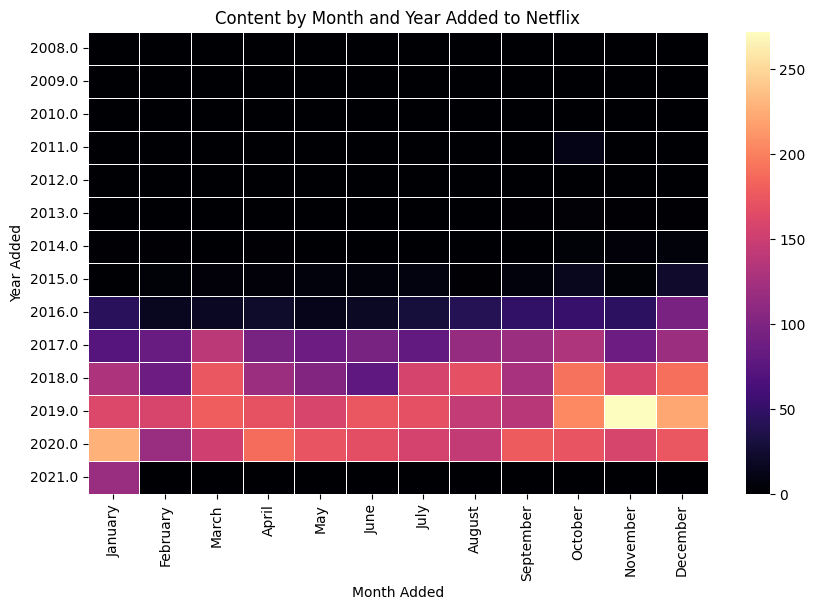

In [29]:
# Create a heatmap from the data in the pivot table
plt.figure(figsize=(10, 6))

sns.heatmap(heatmap_data, cmap = "magma", linewidths = 0.5)

plt.title("Content by Month and Year Added to Netflix")
plt.xlabel("Month Added")
plt.ylabel("Year Added")

plt.show()

In [34]:
!pip install wordcloud 

Defaulting to user installation because normal site-packages is not writeable


In [36]:
import sys
print(sys.executable)

/usr/bin/python3


In [37]:
import sys
!{sys.executable} -m pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [1]:
from wordcloud import WordCloud, STOPWORDS

In [4]:
data_frame.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [5]:
long_text = " ".join(data_frame["description"])

In [6]:
data_frame["description"].head(20)

0     In a future where the elite inhabit an island ...
1     An architect and his wife move into a castle t...
2     Three Indonesian women break records by becomi...
3     New NFL star Thad buys his old teammates' belo...
4     This sequel to the award-winning nature series...
5     Bad news from the past unhinges vagabond Dwigh...
6     A jewel thief returns to his hiding place afte...
7     As Cindy and Dean muddle through their languis...
8     When his girlfriend learns the truth about his...
9     Artists and industry insiders shed light on th...
10    Morphed into a raccoon beastman, Michiru seeks...
11    Members of the Thai idol girl group BNK48 open...
12    Combining his trademark wit and self-deprecati...
13    While attending one of India's premier college...
14    Left brain and right brain duke it out – and u...
15    Staying at home doesn't mean sitting still for...
16    Decades ago, Bob Lazar blew the whistle on Are...
17    "The Joy of Painting" host Bob Ross brings

In [9]:
STOPWORDS.update(["series", "follows", "film", "movie", "show", "brings", "finds", "must"])

In [11]:
wordcloud = WordCloud(width = 1200, height = 600, background_color = "white", stopwords = STOPWORDS, colormap = "viridis").generate(long_text)

In [12]:
wordcloud

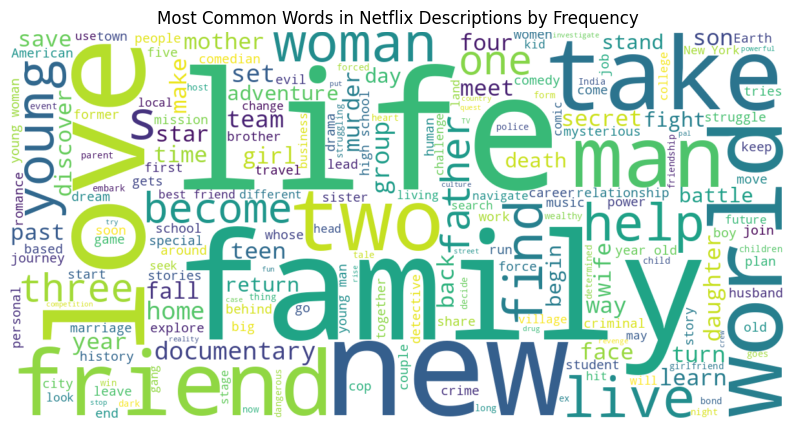

In [13]:
plt.figure(figsize=(10, 6))

plt.imshow(wordcloud, interpolation = "bilinear")

plt.axis("off")

plt.title("Most Common Words in Netflix Descriptions by Frequency")

plt.show()